
# Machine Learning — Notebook 06  
## K-Nearest Neighbors (KNN): escalado, selección de $k$ y validación (CV)

### Objetivos
- Entender KNN como método basado en **distancias** (no paramétrico).
- Ver por qué el **escalado** es crítico en KNN.
- Seleccionar $k$ usando **validación cruzada (K-fold CV)**.
- Comparar contra un **baseline** (`DummyClassifier`).

### Ideas clave
- KNN “aprende” guardando los datos: predice según los $k$ vecinos más cercanos.
- Si las features tienen escalas distintas, las distancias quedan dominadas por la feature con escala grande → KNN falla.
- CV permite elegir $k$ de manera más robusta que un solo split.

> Trabajaremos con datos simulados 2D para visualizar, y luego con un dataset tabular simulado de mayor dimensión.



---
## 0) Setup


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.datasets import make_classification

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)



---
## 1) KNN en 2D: intuición geométrica

Simulamos un dataset 2D para visualizar:
- El clasificador divide el espacio según “regiones de vecindad”.  
- $k$ pequeño → frontera más “rugosa” (alta varianza).  
- $k$ grande → frontera más suave (más sesgo).

En esta sección usamos escalado (aunque en 2D no siempre es necesario si las escalas son comparables).


In [2]:

# 1.1 Datos 2D simulados
X2, y2 = make_classification(
    n_samples=700,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    class_sep=1.1,
    flip_y=0.05,
    random_state=RANDOM_STATE
)


In [3]:
y2

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,

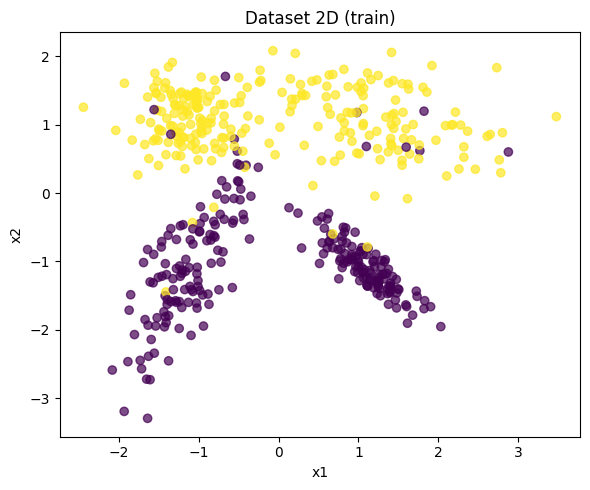

In [4]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=RANDOM_STATE, stratify=y2
)

plt.figure(figsize=(6,5))
plt.scatter(X2_train[:,0], X2_train[:,1], c=y2_train, alpha=0.7)
plt.title("Dataset 2D (train)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

In [5]:

def plot_decision_boundary(model, X, y, title="Decision boundary", steps=250):
    x1_min, x1_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    x2_min, x2_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, steps),
                           np.linspace(x2_min, x2_max, steps))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    proba = model.predict_proba(grid)[:,1].reshape(xx1.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx1, xx2, proba, levels=20)
    plt.colorbar(label="P(y=1|x)")
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", alpha=0.8, s=35)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()


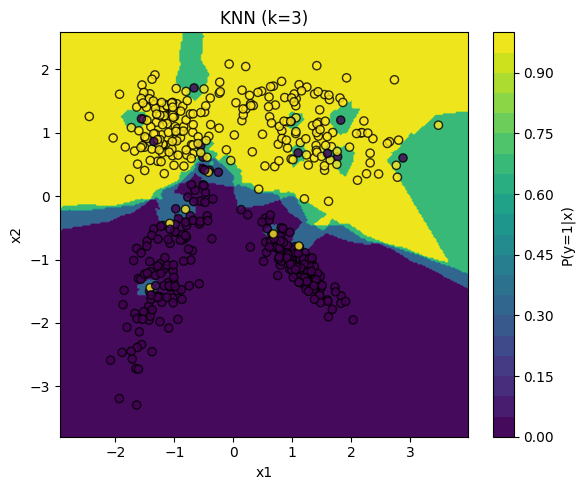

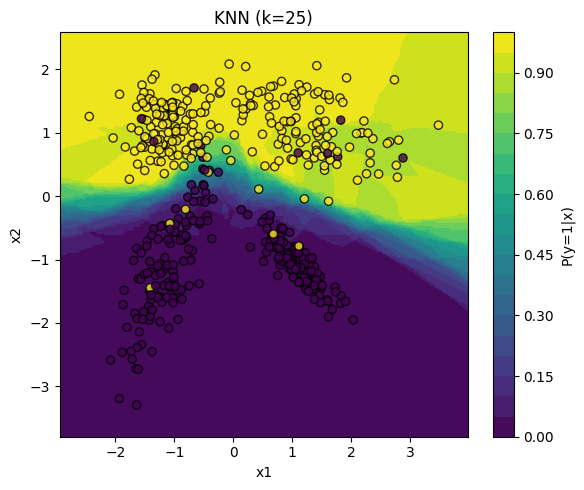

In [6]:

# 1.2 Comparar dos valores de k
knn_k3 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=3))])
knn_k25 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=25))])

knn_k3.fit(X2_train, y2_train)
knn_k25.fit(X2_train, y2_train)

plot_decision_boundary(knn_k3, X2_train, y2_train, title="KNN (k=3)")
plot_decision_boundary(knn_k25, X2_train, y2_train, title="KNN (k=25)")



---
## 2) ¿Por qué el escalado es crítico en KNN? (demo simple)

Creamos un ejemplo donde:
- una feature está en escala pequeña (p.ej. 0–1),
- otra está en escala grande (p.ej. 0–1000).

Sin escalado, la distancia queda dominada por la feature grande y KNN puede fallar.


In [7]:

# 2.1 Dataset donde una feature domina por escala
n = 900
x_small = rng.normal(0, 1, size=n)
x_big = rng.normal(0, 300, size=n)  # escala grande

# Target depende principalmente de x_small
logits = 0.9*x_small + 0.002*x_big + rng.normal(0, 0.7, size=n)
p = 1/(1+np.exp(-logits))
y = rng.binomial(1, p)

X_scale = np.c_[x_small, x_big]

Xtr, Xte, ytr, yte = train_test_split(X_scale, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

# KNN sin escalado
knn_raw = KNeighborsClassifier(n_neighbors=15)
knn_raw.fit(Xtr, ytr)
pred_raw = knn_raw.predict(Xte)

# KNN con escalado (pipeline)
knn_scaled = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=15))])
knn_scaled.fit(Xtr, ytr)
pred_scaled = knn_scaled.predict(Xte)

acc_raw = accuracy_score(yte, pred_raw)
acc_scaled = accuracy_score(yte, pred_scaled)

print("Accuracy KNN sin escalado:", acc_raw)
print("Accuracy KNN con escalado:", acc_scaled)


Accuracy KNN sin escalado: 0.5925925925925926
Accuracy KNN con escalado: 0.6444444444444445



---
## 3) Selección de $k$ con validación cruzada (CV) y comparación con baseline

Usamos un dataset tabular simulado con desbalance moderado.
1) Definimos un grid de $k$.  
2) Calculamos F1 con `StratifiedKFold`.  
3) Elegimos el $k$ que maximiza el promedio CV.  
4) Entrenamos el modelo final y evaluamos en test.


In [8]:

# 3.1 Dataset tabular simulado
X, y = make_classification(
    n_samples=2500,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.75, 0.25],  # desbalance
    class_sep=1.1,
    flip_y=0.03,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, pred_dummy))
print("Baseline balanced acc:", balanced_accuracy_score(y_test, pred_dummy))
print("Baseline F1:", f1_score(y_test, pred_dummy, zero_division=0))


Baseline accuracy: 0.7408
Baseline balanced acc: 0.5
Baseline F1: 0.0


In [9]:

# 3.2 CV para seleccionar k (métrica: F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

k_grid = list(range(1, 51, 2))  # impares: 1..49
rows = []

for k in k_grid:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    rows.append({"k": k, "f1_mean": scores.mean(), "f1_std": scores.std()})

df_k = pd.DataFrame(rows).sort_values("f1_mean", ascending=False)
df_k.head(10)


,k,f1_mean,f1_std
1,3,0.771857,0.025170
2,5,0.766984,0.019871
3,7,0.762191,0.028811
4,9,0.745857,0.031055
5,11,0.741572,0.031175
7,15,0.736684,0.036336
6,13,0.736168,0.032742
0,1,0.730749,0.036490
8,17,0.729903,0.026129
9,19,0.727536,0.022662


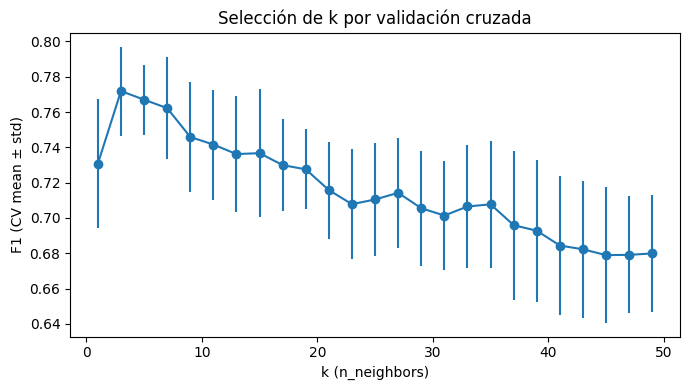

In [10]:

# 3.3 Visualizar desempeño vs k
df_k_sorted = df_k.sort_values("k")

plt.figure(figsize=(7,4))
plt.errorbar(df_k_sorted["k"], df_k_sorted["f1_mean"], yerr=df_k_sorted["f1_std"], fmt="o-")
plt.xlabel("k (n_neighbors)")
plt.ylabel("F1 (CV mean ± std)")
plt.title("Selección de k por validación cruzada")
plt.tight_layout()
plt.show()


In [11]:
df_k_sorted[df_k_sorted["f1_mean"]==df_k_sorted["f1_mean"].max()]

,k,f1_mean,f1_std
1,3,0.771857,0.02517


In [12]:

# 3.4 Entrenar modelo final con el mejor k y evaluar en test
best_k = int(df_k.iloc[0]["k"])
print("Best k:", best_k)

knn_best = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
knn_best.fit(X_train, y_train)

pred = knn_best.predict(X_test)
proba = knn_best.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred)

report = {
    "k": best_k,
    "Accuracy": accuracy_score(y_test, pred),
    "BalancedAcc": balanced_accuracy_score(y_test, pred),
    "F1": f1_score(y_test, pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, proba),
    "PR_AUC": average_precision_score(y_test, proba),
    "TP": cm[1,1], "FP": cm[0,1], "FN": cm[1,0], "TN": cm[0,0]
}
pd.DataFrame([report]).set_index("k")


Best k: 3


,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC,TP,FP,FN,TN
k,,,,,,,,,
3,0.9168,0.855558,0.819444,0.92088,0.834735,118,8,44,455


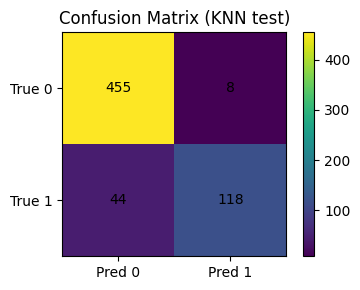

In [13]:

# 3.5 Matriz de confusión (test)
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (KNN test)")
plt.colorbar()
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()



---
## 4) Ejercicios (Semana 6)

### Ejercicio 1 — Escalado
1) Repite la sección 3 eliminando `StandardScaler` del pipeline.  
2) Compara el mejor F1 con y sin escalado. ¿Qué observas y por qué?

### Ejercicio 2 — Grid de k y estabilidad
1) Cambia el grid a `k=1..101` (impares) y observa si el mejor k cambia.  
2) ¿Qué indica un `f1_std` grande en CV?

### Ejercicio 3 — Métrica de selección
1) En vez de F1, usa `balanced_accuracy` como métrica en CV (`scoring="balanced_accuracy"`).  
2) ¿Cambió el mejor k? ¿Qué métrica escogerías en un problema desbalanceado y por qué?

### Ejercicio 4 — Comparación con baseline
1) Reporta accuracy, balanced acc y F1 para el baseline y para KNN.  
2) ¿En qué escenarios un baseline podría “ganar” a KNN?

### Ejercicio 5 — Sesgo-varianza (conceptual)
Explica con tus palabras:
- qué significa “$k$ pequeño” vs “$k$ grande” en sesgo-varianza,
- por qué KNN es sensible a la escala,
- por qué CV es preferible a un solo split para elegir $k$.
